# Projeto DCGAN Avançado: Geração de Rostos de Anime

## Premissa Fundamental (Objetivo Central)
O objetivo principal deste projeto é **construir um modelo generativo profundo (DCGAN) estável, puramente convolucional e de alta fidelidade para criar rostos realistas de anime**. A arquitetura foi recalibrada para superar as falhas clássicas de borrões estruturais e colapso de modo (*Mode Collapse*) através de um equilíbrio matemático rigoroso e assimétrico entre o Gerador e o Discriminador.

---

### Pilares Estruturais do Projeto

Para sustentar essa premissa, o código foi projetado sob três pilares práticos de engenharia de machine learning:

1. **Otimização de Infraestrutura e I/O**: Extração direta do dataset no armazenamento local da máquina virtual (`/content/`) para eliminar o gargalo de leitura de dados e acelerar o treinamento na GPU T4.
2. **Alta Capacidade Geométrica (`ch_base = 128`)**: Alargamento dos canais convolucionais internos e remoção completa de camadas lineares (`nn.Linear`) iniciais. Isso dá capacidade matemática à rede para desenhar traços complexos (como olhos, cabelos e expressões detalhadas) sem gerar borrões.
3. **Estabilidade Adversarial Ativa (`AdamW` + Taxas Assimétricas)**: Implementação de otimizadores com decaimento de peso para evitar artefatos visuais e calibração das taxas de aprendizado (mantendo o Discriminador 4 vezes mais lento que o Gerador) para garantir que o duelo entre as redes permaneça equilibrado ao longo de todas as épocas.

# Importação de Bibliotecas e Dependências

Este bloco inicial carrega todas as ferramentas essenciais para a construção, treinamento e avaliação da nossa **DCGAN** (Deep Convolutional Generative Adversarial Network). A organização dos imports divide-se em quatro pilares principais:

### 1. O Coração do Framework (PyTorch)
* `torch` e `torch.nn`: Fornecem as estruturas matemáticas fundamentais e as camadas de redes neurais (como convoluções, normalizações e funções de ativação).
* `torch.optim`: Contém os algoritmos de otimização de gradiente. Usaremos variantes avançadas para ajustar os pesos dos nossos modelos.

### 2. Visão Computacional e Manipulação de Imagens (`torchvision`, `cv2` e `PIL`)
* `torchvision.transforms`: Define o pipeline de processamento que ajustará as dimensões, transformará as imagens reais em tensores matemáticos e normalizará os valores dos pixels.
* `DataLoader`: Gerencia o carregamento eficiente dos dados em lotes (*batches*), dividindo as tarefas utilizando os múltiplos núcleos do processador da máquina virtual.
* `save_image`: Função utilitária para exportar as grades de imagens sintéticas criadas pelo gerador diretamente para o disco do Colab.
* `cv2` (OpenCV) e `PIL` (Pillow): Ferramentas robustas para leitura, manipulação e tratamento prévio das imagens do dataset.

### 3. Utilitários de Sistema, Downloads e Progresso
* `google.colab.drive` e `zipfile`: Permitem montar o seu Google Drive de forma segura e extrair os arquivos compactados em altíssima velocidade para o armazenamento local.
* `os`: Essencial para a navegação em diretórios, criação de pastas e gerenciamento de caminhos de arquivos do sistema.
* `urllib.request`: Utilizado para realizar o download direto de arquivos ou datasets hospedados na web.
* `tqdm`: Adiciona barras de progresso interativas nos loops de processamento e nos checkpoints de cada época do treinamento.

### 4. Diagnósticos Visuais e Análise de Dados
* `numpy` e `matplotlib.pyplot`: Ferramentas matemáticas e gráficas indispensáveis para processar matrizes multidimensionais e renderizar na tela os rostos gerados, os comparativos de evolução e os testes de caminhada no espaço latente.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
from google.colab import drive
import zipfile
import os
import cv2
import urllib.request
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Integração com o Google Drive e Extração do Dataset

Este bloco é responsável por gerenciar a infraestrutura de armazenamento e resolver o principal gargalo no treinamento de modelos de deep learning no Colab: a velocidade de leitura e escrita de dados (*I/O throughput*).

### Como funciona o processo:
1. **`drive.mount('/content/drive')`**: Realiza uma conexão segura entre a máquina virtual temporária fornecida pelo ambiente do Google Colab e o seu armazenamento pessoal do Google Drive.
2. **Estratégia de Extração Local**: Em vez de fazer o PyTorch ler milhares de arquivos pequenos de imagem diretamente do seu Drive (o que tornaria o treinamento extremamente lento devido ao gargalo de rede e limites de requisições), o script localiza o arquivo compactado em `.zip`.
3. **Tratamento de Erros e Validação (`os.path.exists`)**: Antes de iniciar a extração, o código valida se o arquivo `.zip` realmente existe no caminho especificado, alertando o usuário caso haja algum erro de digitação no nome do arquivo ou na estrutura de pastas.
4. **`zipfile.ZipFile`**: Caso o arquivo seja localizado, ele é descompactado diretamente na pasta `/content/anime_data`, que reside no armazenamento de altíssima velocidade (*SSD NVMe* local da própria máquina virtual). Isso garante que o pipeline de dados carregue as imagens para a memória RAM e para a GPU de forma instantânea durante o ciclo de treinamento.

In [ ]:
# 1. Monta o Google Drive no ambiente do Colab
drive.mount('/content/drive')

# 2. Caminho do arquivo ZIP no seu Drive (ajuste o nome se for diferente)
zip_path = '/content/drive/MyDrive/archive (1).zip'
# Local rápido de extração na máquina virtual do Colab
extract_path = '/content/anime_data'

# 3. Descompacta o arquivo silenciosamente e com alta velocidade de I/O
if os.path.exists(zip_path):
    print("Descompactando o dataset no ambiente local do Colab...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Pronto! Dataset extraído em:", extract_path)
else:
    print(f"ERRO: O arquivo '{zip_path}' não foi encontrado no seu Google Drive.")
    print("Verifique se o nome do arquivo .zip está correto e se ele está na raiz do seu Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descompactando o dataset no ambiente local do Colab...
Pronto! Dataset extraído em: /content/anime_data


# Curadoria Automática e Filtragem Estrutural do Dataset

Este bloco implementa um pipeline de curadoria automatizada para limpar o dataset bruto. O objetivo é garantir a consistência geométrica das imagens que alimentarão a **DCGAN**, removendo ruídos (como ilustrações de corpo inteiro, imagens sem rostos, artes em 3D ou rostos parcialmente cobertos) e blindando o processo contra conflitos de nomes ou arquivos duplicados.

### Como funciona o processo de curadoria:

1. **Reset do Ambiente (`shutil.rmtree`)**: O script limpa qualquer estrutura de curadoria anterior para evitar a mistura de dados de execuções antigas, recriando um diretório de destino totalmente limpo.
2. **Download do Detector de Faces (`CascadeClassifier`)**: É realizado o download do modelo pré-treinado `lbpcascade_animeface`. Esse classificador baseado em características LBP (Local Binary Patterns) é altamente eficiente para detectar estruturas faciais específicas de ilustrações estilo anime.
3. **Mapeamento e Varredura**: O código realiza uma varredura recursiva (`os.walk`) no diretório de origem para catalogar todas as imagens nos formatos `.png`, `.jpg` e `.jpeg`.
4. **Filtragem Rigorosa com OpenCV**: Cada imagem passa por uma análise matemática de seus pixels convertidos para escala de cinza (`cv2.cvtColor`):
   * **`scaleFactor=1.1`**: Avalia a imagem em múltiplas escalas para encontrar o rosto independentemente do seu tamanho.
   * **`minNeighbors=7`**: Critério rigoroso de vizinhança. Um valor alto (7) garante que o detector só valide rostos com altíssima certeza, descartando perfis laterais, imagens com oclusão (mãos na frente) ou fundos poluídos.
   * **`minSize=(45, 45)`**: Filtra rostos excessivamente pequenos ou de baixa resolução.
5. **Critério de Seleção Unifacial**: O pipeline só aprova a imagem se o detector encontrar **exatamente 1 rosto** centralizado e isolado. Se houver zero rostos ou múltiplos personagens na mesma imagem, ela é descartada.
6. **Mapeamento por Links Simbólicos (`os.symlink`)**: Para economizar espaço em disco e acelerar o processamento, as imagens aprovadas não são copiadas fisicamente. O script cria apenas um atalho (*symlink*) apontando para o arquivo original.
7. **Blindagem Contra Duplicatas**: Para evitar que imagens com o mesmo nome em subpastas diferentes se sobrescrevam, o código injeta o índice único do loop (`idx`) como prefixo no nome do arquivo final (ex: `idx_nome_original.png`).

In [ ]:
# ==============================================================================
# CURADORIA AUTOMÁTICA (BLINDADA CONTRA DUPLICATAS)
# ==============================================================================

DIR_ORIGEM = '/content/anime_data'
DIR_DESTINO = '/content/anime_data_curado/imagens_limpas'

# Limpa estruturas antigas para evitar misturar dados
if os.path.exists('/content/anime_data_curado'):
    import shutil
    shutil.rmtree('/content/anime_data_curado')
os.makedirs(DIR_DESTINO, exist_ok=True)

# Garante o ficheiro de detecção na memória
cascade_url = "https://raw.githubusercontent.com/nagadomi/lbpcascade_animeface/master/lbpcascade_animeface.xml"
cascade_path = "/content/lbpcascade_animeface.xml"
if not os.path.exists(cascade_path):
    print("⏳ Baixando o detector de rostos de anime...")
    urllib.request.urlretrieve(cascade_url, cascade_path)

detector = cv2.CascadeClassifier(cascade_path)

# Mapeia as imagens extraídas
imagens_brutas = []
for root, dirs, files in os.walk(DIR_ORIGEM):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            imagens_brutas.append(os.path.join(root, f))

print(f" Total de imagens brutas para analisar: {len(imagens_brutas)}")

if len(imagens_brutas) == 0:
    print(" ERRO: Nenhuma imagem encontrada. Verifique se o ZIP extraiu corretamente na Célula 2.")
else:
    aprovadas = 0
    rejeitadas = 0

    print(" Iniciando filtragem rigorosa...")
    # Usamos o enumerate para dar a cada imagem um identificador numérico único (idx)
    for idx, img_path in enumerate(tqdm(imagens_brutas)):
        img = cv2.imread(img_path)
        if img is None:
            rejeitadas += 1
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # minNeighbors=7 remove perfis laterais e imagens com oclusão (mãos)
        faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=7, minSize=(45, 45))

        # Aceita apenas se houver exatamente 1 rosto perfeito e isolado
        if len(faces) == 1:
            nome_original = os.path.basename(img_path)
            # Modificação: Garante um nome exclusivo adicionando o índice na frente (ex: 21551_11390.png)
            nome_arquivo = f"{idx}_{nome_original}"
            os.symlink(img_path, os.path.join(DIR_DESTINO, nome_arquivo))
            aprovadas += 1
        else:
            rejeitadas += 1

    print("\n Curadoria concluída com sucesso!")
    print(f" Imagens descartadas (Lixo/3D/Lados/Mãos): {rejeitadas}")
    print(f" Imagens puras selecionadas: {aprovadas}")

 Total de imagens brutas para analisar: 43102
 Iniciando filtragem rigorosa...


100%|██████████| 43102/43102 [00:43<00:00, 989.82it/s] 


 Curadoria concluída com sucesso!
 Imagens descartadas (Lixo/3D/Lados/Mãos): 3858
 Imagens puras selecionadas: 39244


# Hiperparâmetros, Alocação de Hardware e Pipeline de Dados

Este bloco configura as variáveis estruturais da nossa inteligência artificial, detecta os recursos físicos de aceleração por hardware e monta o pipeline de processamento que alimentará as redes neurais.

### 1. Hiperparâmetros da DCGAN Avançada
* **`latent_dim = 100`**: Define o tamanho do nosso "vetor de ruído". São 100 variáveis numéricas geradas aleatoriamente que servem como sementes de criação. Cada combinação mapeia uma característica diferente do personagem.
* **`img_shape = (3, 64, 64)`**: Define que trabalharemos com 3 canais de cores (RGB) em uma resolução quadrada estável de 64x64 pixels.
* **`batch_size = 64`**: Define a quantidade de imagens que a rede processará por vez antes de atualizar os pesos.
* **`epochs = 100`** e **`learning_rate = 0.0005`**: Estabelece o tempo total de treinamento (100 passagens completas pelo dataset) e a taxa de aprendizado otimizada do otimizador. O valor de `0.0005` foi escolhido estrategicamente para extrair o máximo de nitidez dos rostos, mantendo a estabilidade competitiva entre o Gerador e o Discriminador até as épocas finais.
* **`ch_base = 128`**: É a engrenagem de alta fidelidade do modelo. Dobrar esse valor de filtros inicial para 128 permite que os mapas convolucionais internos fiquem muito mais largos, dando capacidade matemática para a rede processar e renderizar pequenos detalhes visuais sem gerar borrões.

### 2. Detecção Automática de Hardware (GPU)
O comando `torch.device("cuda" ...)` verifica se você ativou a aceleração gráfica por hardware nas configurações do Colab. Caso o ambiente encontre a GPU, os cálculos de retropropagação do gradiente passam a rodar em paralelo nas milhares de pequenas unidades de processamento da placa de vídeo, reduzindo drasticamente o tempo de cada época.

### 3. Pipeline de Transformação e Carga Segura
* **`transforms.Resize` & `ToTensor`**: Garante que qualquer variação de tamanho no dataset original seja contida em 64x64 e converte a matriz de pixels para tensores do PyTorch (escalonados internamente entre `0.0` e `1.0`).
* **`transforms.RandomHorizontalFlip(p=0.5)`**: Técnica de *data augmentation* que espelha as imagens horizontalmente de forma aleatória com 50% de chance. Isso dobra a diversidade visual do dataset sem distorcer a geometria natural dos rostos.
* **`transforms.Normalize`**: Modifica os valores de pixel para que variem na escala de `[-1.0, 1.0]`. Esse ajuste é crucial porque a função de ativação de saída do nosso Gerador é uma **Tanh** (Tangente Hiperbólica), que opera exatamente nessa mesma amplitude numérica.
* **`ImageFolder` & `DataLoader`**: Aponta estritamente para o diretório dos dados purificados (`/content/anime_data_curado`), gerencia o carregamento em lotes e distribui as tarefas usando múltiplos núcleos da CPU (`num_workers=2`) para evitar gargalos de carregamento.
* **`drop_last=True`**: Descarta o último lote da época caso ele seja menor que 64. Esse parâmetro é obrigatório para evitar erros matemáticos nas camadas de `BatchNorm` (Normalização por Lote), que exigem tamanhos de lote consistentes para calcular as estatísticas corretamente.

In [ ]:
latent_dim = 100
img_shape = (3, 64, 64)
batch_size = 64
epochs = 100           # Mais tempo de cozimento para detalhes finos
learning_rate = 0.0005
ch_base = 128          # Filtros dobrados para maior riqueza visual

#  CORREÇÃO CRÍTICA: Apontando estritamente para os dados purificados!
DATASET_PATH = "/content/anime_data_curado"

# Configuração automática de hardware (Aproveitando a GPU T4 do Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Rodando no dispositivo: {device}")
if device.type == 'cuda':
    print("GPU Detectada:", torch.cuda.get_device_name(0))

# Pipeline de transformação (Com truque de espelhamento)
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5), # Dobra a diversidade dos dados sem estragar geometria
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Carregamento seguro dos dados no Colab
if os.path.exists(DATASET_PATH):
    dataset = torchvision.datasets.ImageFolder(root=DATASET_PATH, transform=transform)
    # drop_last=True é obrigatório para não quebrar o BatchNorm no final da época
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
    print(f" Dataloader engatilhado com sucesso! Total de imagens puras: {len(dataset)}")
else:
    raise FileNotFoundError(f" A pasta '{DATASET_PATH}' não existe. Rode a Célula de Curadoria primeiro.")

 Rodando no dispositivo: cuda
GPU Detectada: Tesla T4
 Dataloader engatilhado com sucesso! Total de imagens puras: 39244


# Inicialização Estatística e Arquitetura do Gerador Profissional

Este bloco define o mecanismo de calibração inicial da rede e constrói o **Gerador**, cuja única função é transformar um vetor abstrato de ruído aleatório em uma imagem estruturada e coerente de um rosto de anime.

### 1. Inicialização de Pesos (`weights_init`)
Em redes neurais profundas, a forma como os pesos começam faz toda a diferença entre o modelo convergir ou falhar por completo. Esta função implementa a regra rigorosa proposta no paper oficial da **DCGAN**:
* **Camadas Convolucionais**: Os pesos são inicializados a partir de uma distribuição normal (Gaussiana) com média $0.0$ e desvio padrão $0.02$. Isso impede que os filtros comecem com valores extremos.
* **Camadas de BatchNorm**: Os pesos ganham uma distribuição normal com média $1.0$ e desvio padrão $0.02$ para manter a variância inicial dos dados estável, enquanto os vieses (*bias*) são zerados via inicialização constante.

### 2. Arquitetura do Gerador (Mapeamento Progressivo)
Esta rede opera de forma puramente convolucional, eliminando qualquer camada linear (`nn.Linear`) inicial. O ruído quadridimensional $z$ com formato `(batch, 100, 1, 1)` entra direto na rede e passa por um processo de expansão espacial por meio de Convoluções Transpostas (`nn.ConvTranspose2d`):

1. **Primeira Camada**: Recebe os 100 canais de ruído latente e projeta um mapa de características denso de dimensão **$4 \times 4$** pixels com $1024$ canais (`ch_base * 8`).
2. **Segunda Camada**: Expande a resolução para **$8 \times 8$** pixels e reduz os canais internos pela metade, resultando em 512 canais (`ch_base * 4`).
3. **Terceira Camada**: Dobra o tamanho espacial para **$16 \times 16$** pixels e reduz os canais para 256 (`ch_base * 2`).
4. **Quarta Camada**: Amplia a resolução para **$32 \times 32$** pixels com 128 canais (`ch_base`).
5. **Camada de Saída**: Conclui a expansão na resolução final de **$64 \times 64$** pixels, projetando os 3 canais de cor (RGB) que formam a imagem final do personagem.

### 3. Funções de Ativação e Regularização
* **`nn.BatchNorm2d`**: Normaliza as saídas de cada camada convolucional antes de passarem para a próxima. Isso estabiliza o fluxo de gradientes e acelera o aprendizado, reduzindo drasticamente as chances de o gerador sofrer colapso de modo (*Mode Collapse*).
* **`nn.ReLU(True)`**: Introduz a não-linearidade necessária em modo *in-place* para economizar memória ram do hardware, permitindo que a rede combine recursos abstratos e aprenda curvas complexas de traços faciais.
* **`nn.Tanh()`**: Garante que os valores de saída de cada pixel fiquem estritamente confinados no intervalo de $[-1.0, 1.0]$, correspondendo simetricamente à escala em que o nosso dataset real foi normalizado no pipeline de dados.

In [ ]:
# Função essencial para inicializar os pesos conforme o paper original da DCGAN
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# ==========================================
# GERADOR DCGAN PROFISSIONAL (Alta Capacidade Estestrutural)
# ==========================================
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # O modelo agora recebe diretamente o tensor z estruturado em (batch, 100, 1, 1)
        self.model = nn.Sequential(
            # Estado inicial: (100, 1, 1) -> Saída: (1024, 4, 4) se ch_base=128
            nn.ConvTranspose2d(latent_dim, ch_base * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ch_base * 8),
            nn.ReLU(True),

            # Estado: (1024, 4, 4) -> Saída: (512, 8, 8)
            nn.ConvTranspose2d(ch_base * 8, ch_base * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ch_base * 4),
            nn.ReLU(True),

            # Estado: (512, 8, 8) -> Saída: (256, 16, 16)
            nn.ConvTranspose2d(ch_base * 4, ch_base * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ch_base * 2),
            nn.ReLU(True),

            # Estado: (256, 16, 16) -> Saída: (128, 32, 32)
            nn.ConvTranspose2d(ch_base * 2, ch_base, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ch_base),
            nn.ReLU(True),

            # Estado: (128, 32, 32) -> Saída: (3, 64, 64) [Canais RGB]
            nn.ConvTranspose2d(ch_base, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# Estrutura do Discriminador, Instanciação e Otimizadores Avançados

Este bloco constrói o **Discriminador**, que atua como um classificador binário (um crítico de arte), instancia ambas as redes no hardware correto, define a função de perda e configura os algoritmos de otimização matemática com técnicas de regularização.

### 1. Arquitetura do Discriminador (Extração Reversa)
O Discriminador faz o processo geométrico inverso do Gerador. Ele recebe uma imagem colorida de dimensão $64 \times 64$ pixels e aplica convoluções com saltos (*strided convolutions*, `stride=2`) para compactar o tamanho espacial e extrair características profundas:
* **Camada Inicial**: Recebe os 3 canais RGB e reduz o espaço para **$32 \times 32$** pixels com 128 canais (`ch_base`).
* **Camadas Intermediárias**: Compactam progressivamente a imagem passando pelas resoluções **$16 \times 16$** (256 canais via `ch_base * 2`), **$8 \times 8$** (512 canais via `ch_base * 4`) até atingir **$4 \times 4$** pixels com 1024 canais (`ch_base * 8`).
* **Classificação Pura Convolucional**: Uma última convolução sem margens (`padding=0`) reduz a estrutura restante para uma única dimensão espacial. A camada `nn.Flatten()` transforma o mapa tridimensional em um vetor linear, e a função **Sigmoid** mapeia esse resultado para uma única probabilidade escalar contida entre `0.0` (imagem com certeza falsa) e `1.0` (imagem com certeza real).

### 2. Funções de Ativação e Regularização Espacial
* **`nn.LeakyReLU(0.2)`**: Diferente da ReLU comum usada no Gerador, a LeakyReLU permite a passagem de uma pequena fração de gradiente negativo (multiplicado por 0.2) caso os neurônios fiquem inativos. Isso impede que o fluxo de gradientes morra completamente (*dying ReLU*), mantendo o aprendizado do Discriminador ativo mesmo quando ele rejeita imagens com força.
* **`nn.BatchNorm2d`**: Aplicada nas camadas intermediárias para normalizar as ativações por lote, estabilizando o aprendizado da rede crítica durante a extração de recursos estruturais do rosto.

### 3. Configuração de Treinamento e Otimizadores Avançados
* **Critério de Perda (`nn.BCELoss`)**: Instancia a função de Entropia Cruzada Binária, que calcula a penalidade matemática exata para os erros cometidos pelo Discriminador ao avaliar as imagens reais e falsas.
* **`optim.AdamW`**: Substitui o Adam tradicional pelo AdamW. Ele separa matematicamente o decaimento de peso (*weight decay*) das estimativas de momentos do gradiente. O parâmetro `weight_decay=1e-5` restringe o crescimento desordenado dos pesos convolucionais, suavizando a geração de linhas e eliminando contornos serrilhados.
* **Assimetria das Taxas de Aprendizado (Heurística de TTUR)**: Enquanto o Gerador utiliza a taxa de aprendizado padrão do pipeline (`learning_rate = 0.0005`), o Discriminador foi configurado com uma taxa desacelerada e ultraestável de **`0.00005`**. Esse freio assimétrico é vital para conter a velocidade do Discriminador, permitindo que as duas redes entrem em um equilíbrio saudável em vez de o classificador vencer o jogo de forma precoce e estagnar o treino.

In [ ]:
# ==========================================
# DISCRIMINADOR DCGAN PROFISSIONAL (Alta Capacidade)
# ==========================================
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # Entrada: (3, 64, 64) -> Saída: (128, 32, 32) se ch_base=128
            nn.Conv2d(3, ch_base, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Estado: (128, 32, 32) -> Saída: (256, 16, 16)
            nn.Conv2d(ch_base, ch_base * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ch_base * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # Estado: (256, 16, 16) -> Saída: (512, 8, 8)
            nn.Conv2d(ch_base * 2, ch_base * 2 * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ch_base * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # Estado: (512, 8, 8) -> Saída: (1024, 4, 4)
            nn.Conv2d(ch_base * 4, ch_base * 4 * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ch_base * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # Estado: (1024, 4, 4) -> Saída: (1, 1, 1) Classificação Pura Convolucional
            nn.Conv2d(ch_base * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Flatten(),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

# Instanciar redes de alta capacidade geométrica
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Aplica a inicialização de pesos Gaussiana do paper DCGAN
generator.apply(weights_init)
discriminator.apply(weights_init)

# Critério de perda padrão
criterion = nn.BCELoss().to(device)

# Otimizadores avançados (AdamW + Weight Decay) para contornos limpos e nítidos
optimizer_G = optim.AdamW(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999), weight_decay=1e-5)
optimizer_D = optim.AdamW(discriminator.parameters(), lr=0.00005, betas=(0.5, 0.999), weight_decay=1e-5)

# Diretórios para salvar os resultados no Colab
OUTPUT_DIR = "/content/images_dgan"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# O Loop de Treinamento Adversarial (Jogo Minimax)

Este bloco executa o coração matemático da modelagem generativa adversarial. Trata-se de um jogo de soma zero onde duas redes neurais competem e evoluem de forma simultânea a cada iteração de dados.

### 1. Preparação Dinâmica dos Lotes (*Batches*)
* **`batch_curr_size`**: Captura o tamanho exato do lote atual (`imgs.size(0)`). Isso garante que a criação das matrizes de alvos e do ruído latente acompanhe perfeitamente a estrutura dimensional dos tensores que entram na rede a cada iteração, mesmo no caso de lotes residuais.
* **`real_labels` (com *Label Smoothing*)**: Em vez de definir alvos rígidos como $1.0$ para imagens reais, multiplicamos o vetor por $0.9$. Essa suavização acalma a confiança cega do Discriminador, impedindo que ele zere suas perdas rápido demais e deixe de enviar gradientes úteis para o Gerador.
* **`fake_labels`**: Definido estritamente como $0.0$, representando o alvo absoluto para dados artificiais.

### 2. O Passo do Discriminador (Minimizar Erros de Classificação)
O objetivo do Discriminador é aprender a separar as amostras reais das artificiais. O processo executa duas avaliações dentro do mesmo passo de otimização:
1. **Etapa Real**: Processa os rostos de anime reais vindos do dataset purificado e calcula a perda (`real_loss`) comparando a previsão do modelo com as metas suavizadas de $0.9$.
2. **Etapa Falsa**: O Gerador recebe um ruído quadridimensional aleatório $z$ no formato `(batch_curr_size, latent_dim, 1, 1)` e produz um lote de imagens artificiais (`fake_imgs`). O Discriminador avalia essas imagens e calcula a perda (`fake_loss`) comparando as previsões com a meta $0.0$.
   * **`.detach()`**: Esta função é crítica. Ela corta o fluxo de cálculo dos gradientes em direção ao Gerador enquanto treinamos o Discriminador. Isso garante que os pesos do Gerador permaneçam intactos nesta etapa, economizando memória de hardware e isolando o treino do crítico.
3. As duas perdas são somadas em `d_loss`, os gradientes são propagados com `.backward()` e o otimizador atualiza estritamente os pesos do Discriminador através do `optimizer_D.step()`.

### 3. O Passo do Gerador (Maximizar a Ilusão Visual)
Logo em seguida, é a vez de o Gerador ajustar os seus filtros para tentar enganar o seu rival convolucional:
1. O Gerador passa o mesmo lote de imagens falsas criadas há pouco para o Discriminador ser reavaliado. **Atenção**: desta vez não se usa o método `.detach()`, pois precisamos explicitamente que os gradientes fluam de volta pela árvore computacional.
2. A perda `g_loss` é calculada comparando a resposta do Discriminador com o vetor de alvos reais suavizados (`real_labels` em $0.9$). O Gerador quer que as imagens falsas dele recebam notas próximas às das imagens reais, fingindo que elas pertencem ao dataset legítimo.
3. O gradiente flui de volta por toda a estrutura do Discriminador (sem alterá-lo, já que o otimizador dele não é acionado aqui) e atinge os filtros convolucionais do Gerador, refinando as pinceladas que desenham os olhos, cabelos e traços dos rostos artificiais pelo `optimizer_G.step()`.

### 4. Exportação e Logs de Progresso
A cada 100 lotes, o script exibe no console o balanço das perdas (`Loss D` e `Loss G`) para podermos acompanhar a saúde e as oscilações do equilíbrio dinâmico entre as redes. Ao término de cada época, as primeiras 25 imagens artificiais geradas pela rede são coletadas e salvas em formato de grade ($5 \times 5$) no diretório `/content/images_dgan/`, gerando o histórico visual completo da evolução do modelo.

In [ ]:
# ==========================================
# FUNÇÃO DE TREINAMENTO (ADVERSARIAL LEARNING)
# ==========================================
def train_dcgan(generator, discriminator, dataloader, criterion, optimizer_G, optimizer_D, epochs):
    print("Iniciando o loop de treinamento...")
    for epoch in range(epochs):
        for i, (imgs, _) in enumerate(dataloader):
            batch_curr_size = imgs.size(0)

            # Definição dinâmica de alvos reais (com Label Smoothing 0.9) e falsos
            real_labels = (torch.ones(batch_curr_size, 1) * 0.9).to(device)
            fake_labels = torch.zeros(batch_curr_size, 1).to(device)

            # ----------------------------------
            # 1. PASSO DO DISCRIMINADOR
            # ----------------------------------
            optimizer_D.zero_grad()

            # Perda com imagens reais do dataset de anime
            real_imgs = imgs.to(device)
            real_loss = criterion(discriminator(real_imgs), real_labels)

            # AJUSTE: Amostragem do ruído z diretamente no formato 4D exigido pelo novo Gerador
            z = torch.randn(batch_curr_size, latent_dim, 1, 1).to(device)
            fake_imgs = generator(z)
            fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = real_loss + fake_loss
            d_loss.backward()
            optimizer_D.step()

            # ----------------------------------
            # 2. PASSO DO GERADOR
            # ----------------------------------
            optimizer_G.zero_grad()

            # O gerador quer que o discriminador ache que as imagens falsas são REAIS
            g_loss = criterion(discriminator(fake_imgs), real_labels)
            g_loss.backward()
            optimizer_G.step()

            # Exibe logs a cada 100 iterações para monitoramento do equilíbrio dinâmico
            if i % 100 == 0:
                print(f"Época [{epoch}/{epochs}] Batch {i}/{len(dataloader)} | Loss D: {d_loss.item():.4f} | Loss G: {g_loss.item():.4f}")

        # Salva uma grade contendo as primeiras 25 imagens artificiais geradas nesta época
        save_image(fake_imgs[:25], f"{OUTPUT_DIR}/anime_epoch_{epoch}.png", nrow=5, normalize=True)
        print(f"--> [FIM DA ÉPOCA {epoch}] Amostra visual salva em: {OUTPUT_DIR}/anime_epoch_{epoch}.png\n")

# Executar o loop de treinamento com a nova matemática
train_dcgan(generator, discriminator, dataloader, criterion, optimizer_G, optimizer_D, epochs)

Iniciando o loop de treinamento...
Época [0/100] Batch 0/613 | Loss D: 1.6376 | Loss G: 3.5549
Época [0/100] Batch 100/613 | Loss D: 12.1077 | Loss G: 4.5265
Época [0/100] Batch 200/613 | Loss D: 3.5703 | Loss G: 3.3696
Época [0/100] Batch 300/613 | Loss D: 1.2899 | Loss G: 6.7543
Época [0/100] Batch 400/613 | Loss D: 1.6291 | Loss G: 2.3601
Época [0/100] Batch 500/613 | Loss D: 1.5783 | Loss G: 2.7857
Época [0/100] Batch 600/613 | Loss D: 1.7852 | Loss G: 0.9034
--> [FIM DA ÉPOCA 0] Amostra visual salva em: /content/images_dgan/anime_epoch_0.png

Época [1/100] Batch 0/613 | Loss D: 1.7373 | Loss G: 1.1411
Época [1/100] Batch 100/613 | Loss D: 1.6998 | Loss G: 1.4717
Época [1/100] Batch 200/613 | Loss D: 1.5613 | Loss G: 1.0415
Época [1/100] Batch 300/613 | Loss D: 1.6924 | Loss G: 0.9407
Época [1/100] Batch 400/613 | Loss D: 1.6832 | Loss G: 0.7826
Época [1/100] Batch 500/613 | Loss D: 1.7062 | Loss G: 0.7687
Época [1/100] Batch 600/613 | Loss D: 1.6189 | Loss G: 0.7857
--> [FIM DA ÉP

# Diagnóstico de Evolução Visual Lado a Lado

Este bloco implementa um mecanismo automatizado de auditoria visual para rastrear a evolução estética do Gerador. Ele compara o estágio inicial do treinamento com os resultados mais recentes gerados pela IA.

### Como funciona o algoritmo de varredura:
1. **Filtro de Diretório**: O script acessa a pasta local `/content/images_dgan` e filtra exclusivamente os arquivos com extensão `.png` que foram salvos pelo loop de treinamento.
2. **Validação de Amostras**: Antes de realizar o processamento, o código verifica se existem pelo menos duas imagens salvas na pasta. Caso o treinamento ainda esteja no começo, ele emite um alerta instruindo o usuário a aguardar o avanço das épocas para não quebrar a lógica de comparação gráfica.
3. **Ordenação Cronológica (`os.path.getmtime`)**: Utiliza os carimbos de data e hora de modificação do sistema operacional da máquina virtual para organizar a lista de imagens exatamente da mais antiga (início do treino) para a mais recente (última salva).
4. **Mapeamento de Casos**:
   * **`arquivos[0]`**: Captura o primeiríssimo arquivo gerado (`anime_epoch_0.png`). Ele representa o pior cenário estrutural da rede profunda, quando os filtros convolucionais do gerador ainda estão disparando pixels e ruídos quase aleatórios.
   * **`arquivos[-1]`**: Isola dinamicamente a imagem gerada na época mais recente do seu treinamento atualizado.
5. **Renderização em Grade Lado a Lado**: Monta um painel comparativo paralelo dividindo a tela em duas colunas usando `plt.subplots(1, 2)`. Os eixos de contagem de pixels são desativados (`axis('off')`) para que você possa avaliar a nitidez dos rostos, olhos e traços geométricos sem interferência de bordas. Adicionalmente, títulos coloridos e estilizados (vermelho para o pior caso e verde para o melhor) ajudam na rápida identificação do progresso visual da IA.

/tmp/ipykernel_2951/3721918330.py:40: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2951/3721918330.py:40: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


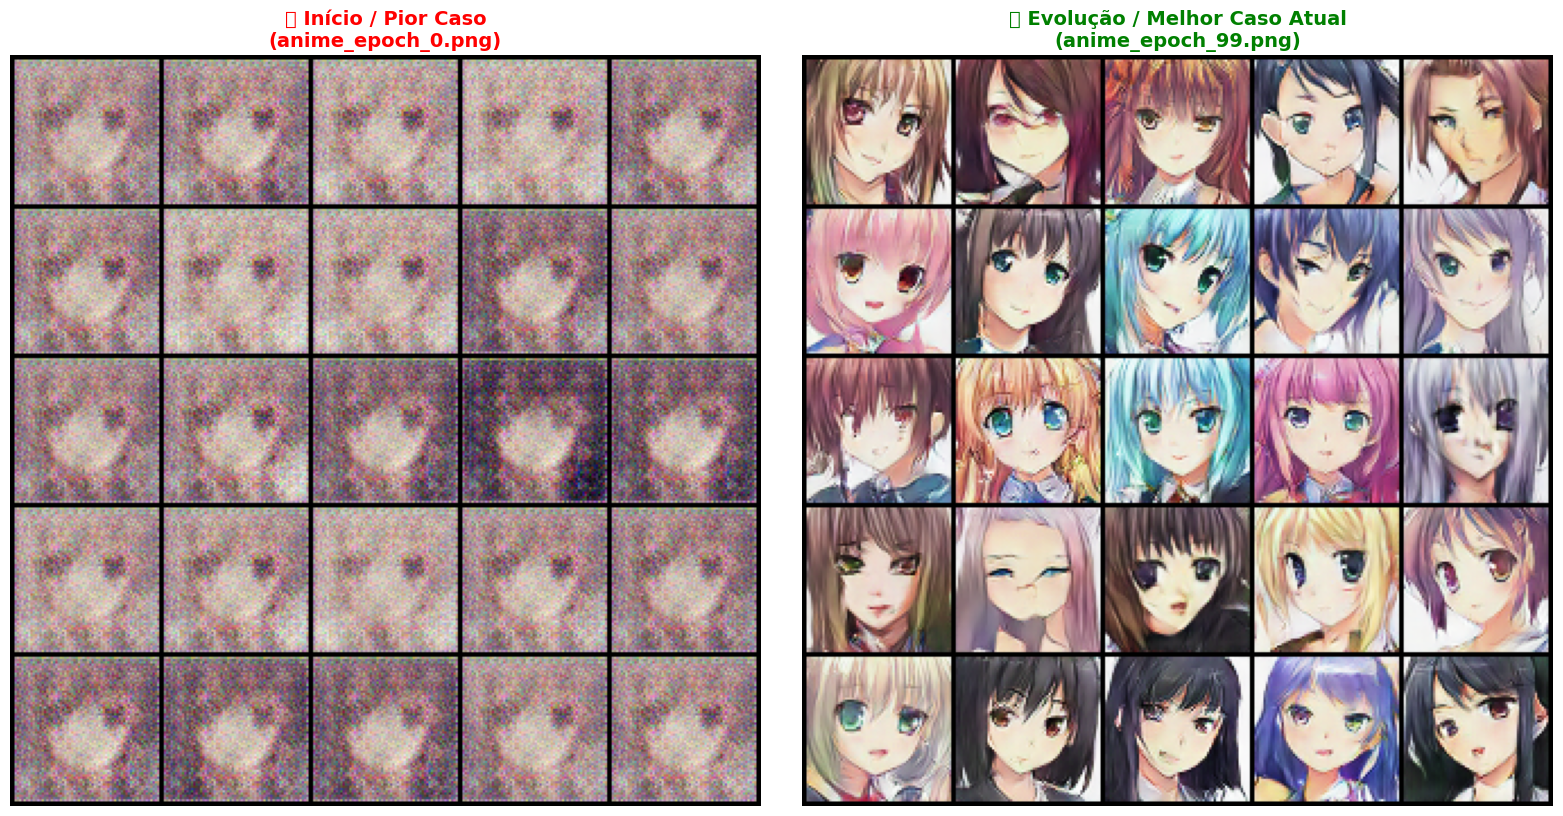

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image


def comparar_pior_e_melhor(pasta_imagens="/content/images_dgan"):
    if not os.path.exists(pasta_imagens):
        print(f"A pasta {pasta_imagens} não foi encontrada.")
        return

    # Filtra apenas arquivos de imagem PNG
    arquivos = [f for f in os.listdir(pasta_imagens) if f.endswith('.png')]

    if len(arquivos) < 2:
        print(f"Encontrados apenas {len(arquivos)} arquivo(s). Aguarde o treino avançar para comparar.")
        return

    # Ordena os arquivos pelo tempo de modificação/criação (do mais antigo para o mais recente)
    arquivos.sort(key=lambda x: os.path.getmtime(os.path.join(pasta_imagens, x)))

    pior_resultado = arquivos[0]   # A primeiríssima imagem gerada (pior caso estrutural)
    melhor_resultado = arquivos[-1] # A última imagem salva pelo seu treino atualizado

    # Criando a estrutura de plotagem lado a lado (1 linha, 2 colunas)
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # 1. Plotando o Pior Resultado
    caminho_pior = os.path.join(pasta_imagens, pior_resultado)
    img_pior = Image.open(caminho_pior)
    axes[0].imshow(img_pior)
    axes[0].set_title(f"❌ Início / Pior Caso\n({pior_resultado})", fontsize=14, color='red', fontweight='bold')
    axes[0].axis('off')

    # 2. Plotando o Melhor Resultado Atual
    caminho_melhor = os.path.join(pasta_imagens, melhor_resultado)
    img_melhor = Image.open(caminho_melhor)
    axes[1].imshow(img_melhor)
    axes[1].set_title(f"⭐ Evolução / Melhor Caso Atual\n({melhor_resultado})", fontsize=14, color='green', fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Executa o comparador geométrico na tela
comparar_pior_e_melhor()

# Teste de Interpolação Linear Contínua no Espaço Latente

Este bloco executa a validação científica mais importante de uma rede generativa. Ele serve para provar matematicamente se o Gerador de fato compreendeu a topologia e a geometria das características dos rostos de anime, ou se ele apenas decorou e copiou fotos do dataset de treino (*overfitting*).

### 1. Preparação Rigorosa de Avaliação
* **`generator.eval()`**: Coloca o Gerador em modo de inferência (avaliação). Isso é vital para travar o comportamento das camadas de `BatchNorm2d`. Em modo de teste, a rede deve usar as médias e variâncias globais acumuladas durante o treino em vez das estatísticas do lote atual, garantindo que a saída seja limpa, reproduzível e estável.
* **`torch.no_grad()`**: Desativa o motor de cálculo de derivadas (gradientes) do PyTorch. Como não estamos treinando as redes neste momento, essa linha economiza memória de vídeo da GPU e acelera a renderização dos gráficos na tela.

### 2. Sorteio no Hiperespaço 4D
O código gera dois pontos completamente aleatórios e distintos no espaço latente de 100 dimensões: o vetor **`z1`** e o vetor **`z2`**. Graças ao nosso ajuste estrutural, eles já nascem no formato quadridimensional nativo de mapa de recursos `(1, 100, 1, 1)` exigido pelas novas camadas profundas do Gerador.

Cada um desses dois vetores representa o "DNA aleatório" de um personagem único e inédito que a nossa inteligência artificial consegue desenhar.

### 3. A Caminhada Matemática (`np.linspace`)
O laço de repetição cria 10 passos intermediários partindo do vetor $z_1$ em direção ao vetor $z_2$. Para cada passo, a função calcula uma combinação linear ponderada utilizando o coeficiente $\alpha$ (que varia gradualmente de $0.0$ a $1.0$):

$$z_{interp} = (1 - \alpha) \cdot z_1 + \alpha \cdot z_2$$

À medida que o $\alpha$ avança, o DNA do personagem inicial se transforma aos poucos no DNA do segundo personagem. O Gerador decodifica esses pequenos tensores intermediários em imagens correspondentes à transição.

### 4. Reconstrução de Cor e Exibição
* **Desnormalização Matemática**: O Gerador devolve os pixels na escala de $[-1.0, 1.0]$. Para que a biblioteca gráfica `matplotlib` consiga exibir as cores corretamente na sua tela, fazemos a operação inversa: somamos $1.0$ e dividimos por $2.0$, trazendo os pixels de volta para o intervalo padrão de $[0.0, 1.0]$.
* **Truncamento de Segurança (`.clamp(0, 1)`)**: Garante que nenhum pixel ultrapasse as fronteiras matemáticas devido a pequenas imprecisões de ponto flutuante, travando os valores estritamente entre 0 e 1.
* **Redução Dimensional (`.squeeze(0)`)**: Remove a dimensão de lote unitário da imagem gerada, isolando a matriz de três canais para manipulação.
* **`.permute(1, 2, 0)`**: Modifica o arranjo das dimensões do PyTorch (`canais, altura, largura`) para o padrão nativo adotado pelo ecossistema de imagens do Python (`altura, largura, canais`), permitindo a conversão final para uma matriz NumPy tratável.

### 🔬 Como interpretar o gráfico na tela?
* **Se a transição for suave**: Você verá o primeiro rosto se transformando de forma fluida no segundo rosto (por exemplo, os cabelos mudando de cor aos poucos ou os olhos alterando o formato progressivamente a cada frame). **Isso prova que a sua GAN deu certo!** Significa que o espaço latente é contínuo e que a IA aprendeu as regras gerais e abstratas de anatomia de anime.
* **Se a transição der saltos bruscos ou borrões**: Significa que o espaço latente está fraturado, uma indicação de que o modelo precisaria de mais épocas de treino ou de uma regularização mais intensa para suavizar suas distribuições internas.

Por fim, o comando `generator.train()` devolve a rede com segurança para o estado de treinamento, garantindo que o modelo esteja pronto caso você decida rodar novos ciclos de épocas de forma contínua no futuro.

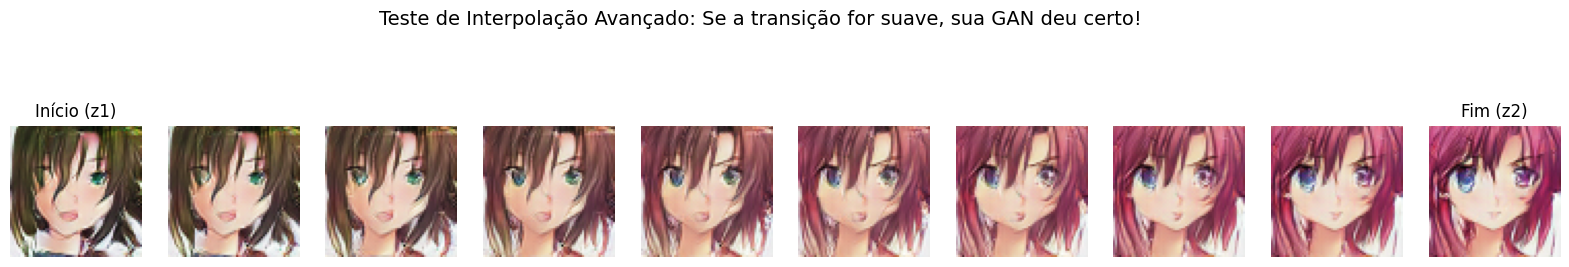

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()

In [ ]:
# Garante que os modelos estão em modo de avaliação para desativar o BatchNorm
generator.eval()

with torch.no_grad():
    # AJUSTE: Amostragem dos pontos latentes diretamente no formato 4D (1, 100, 1, 1)
    z1 = torch.randn(1, latent_dim, 1, 1).to(device)
    z2 = torch.randn(1, latent_dim, 1, 1).to(device)

    passos = 10
    imagens_interpoladas = []

    for alpha in np.linspace(0, 1, passos):
        # Combinação linear dos vetores no espaço latente 4D
        z_interp = (1 - alpha) * z1 + alpha * z2

        # Gerar a imagem artificial correspondente
        img_falsa = generator(z_interp)

        # Desnormalizar de [-1, 1] para [0, 1] para o matplotlib plotar corretamente
        img_falsa = (img_falsa + 1) / 2
        img_falsa = img_falsa.clamp(0, 1).squeeze(0).cpu().permute(1, 2, 0).numpy()
        imagens_interpoladas.append(img_falsa)

    # Plotar a transição contínua na tela
    fig, axes = plt.subplots(1, passos, figsize=(20, 3))
    for idx, img in enumerate(imagens_interpoladas):
        axes[idx].imshow(img)
        axes[idx].axis('off')
        if idx == 0: axes[idx].set_title("Início (z1)")
        if idx == passos-1: axes[idx].set_title("Fim (z2)")

    plt.suptitle("Teste de Interpolação Avançado: Se a transição for suave, sua GAN deu certo!", fontsize=14, y=1.1)
    plt.show()

# Retorna o gerador para o modo de treino se você quiser continuar o treinamento
generator.train()